# Notebook 23 — MASTER RESULTS (FINAL): All Models, All Datasets

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

FIG = Path("../reports/figures"); TAB = Path("../reports/tables")
for d in (FIG, TAB): d.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 11})
INK = ["#2b2b2b", "#6f6f6f", "#a3a3a3", "#cccccc"]
BLUE = "#1a4f8a"; GREEN = "#2e7d32"; RED = "#8a1a1a"

## 1. Multi-seed custom results (real per-seed values)

In [2]:
ms_path = Path("../checkpoints/multiseed/results.csv")
if ms_path.exists():
    seed_df = pd.read_csv(ms_path)
else:
    seed_df = pd.DataFrame({
        "seed":[42,43,44,45,46],
        "M0_EM":[0.20607,0.12516,0.18963,0.06700,0.21365],
        "M0_CER":[0.45928,0.48403,0.46981,0.55716,0.43416],
        "M2_EM":[0.35145,0.29456,0.34766,0.19343,0.38812],
        "M2_CER":[0.46482,0.48735,0.47054,0.58172,0.42862]})
m0_em, m0_sd = seed_df["M0_EM"].mean(), seed_df["M0_EM"].std(ddof=1)
m2_em, m2_sd = seed_df["M2_EM"].mean(), seed_df["M2_EM"].std(ddof=1)
m0_cer = seed_df["M0_CER"].mean(); m2_cer = seed_df["M2_CER"].mean()

## 2. All final results (custom dataset, test set)
Each: CER, EM (overall), EM_sd (None=single run), seen, unseen, note.

In [3]:
custom = {
    "CRNN (baseline)":            {"CER":m0_cer,"EM":m0_em,"EM_sd":m0_sd,"seen":0.206,"unseen":0.000,"note":"from scratch, 5-seed"},
    "CRNN + Transformer":         {"CER":0.474,"EM":0.222,"EM_sd":None,"seen":0.287,"unseen":0.000,"note":"negative result"},
    "CRNN + BiLSTM + Transformer":{"CER":0.597,"EM":0.140,"EM_sd":None,"seen":0.181,"unseen":0.000,"note":"negative result"},
    "Attention decoder":         {"CER":0.846,"EM":0.000,"EM_sd":None,"seen":0.000,"unseen":0.000,"note":"failed to converge"},
    "CRNN + lexicon":            {"CER":m2_cer,"EM":m2_em,"EM_sd":m2_sd,"seen":0.405,"unseen":0.000,"note":"from scratch, 5-seed"},
    "TrOCR (fine-tuned)":        {"CER":0.216,"EM":0.569,"EM_sd":None,"seen":0.701,"unseen":0.108,"note":"61.6M, pretrained"},
    "TrOCR + training lexicon":  {"CER":0.220,"EM":0.612,"EM_sd":None,"seen":0.779,"unseen":0.028,"note":""},
    "TrOCR + external formulary":{"CER":0.204,"EM":0.659,"EM_sd":None,"seen":0.774,"unseen":0.256,"note":"formulary recovers unseen"},
    "Augmented TrOCR":           {"CER":0.176,"EM":0.655,"EM_sd":None,"seen":0.810,"unseen":0.114,"note":"augmentation improves recognition"},
    "Augmented TrOCR + formulary":{"CER":0.167,"EM":0.721,"EM_sd":None,"seen":0.841,"unseen":0.301,"note":"BEST — combined"},
}

## 2.1  >>> ADD ANY EARLIER MODELS HERE <<<  (optional)

In [4]:
extra_models = {
    # "Name": {"CER":0.0,"EM":0.0,"EM_sd":None,"seen":0.0,"unseen":0.0,"note":""},
}
custom.update(extra_models)
print(f"{len(custom)} models in custom comparison")

10 models in custom comparison


## 3. Master comparison table

In [5]:
def fmt(v, sd): return f"{v:.3f} ± {sd:.3f}" if sd is not None else f"{v:.3f}"
rows=[{"Model":k,"CER":f"{d['CER']:.3f}","Exact Match":fmt(d["EM"],d["EM_sd"]),
       "Seen EM":f"{d['seen']:.3f}","Unseen EM":f"{d['unseen']:.3f}","Notes":d["note"]}
      for k,d in custom.items()]
master = pd.DataFrame(rows)
master.to_csv(TAB/"FINAL_master_comparison.csv", index=False)
print(master.to_string(index=False))

                      Model   CER   Exact Match Seen EM Unseen EM                             Notes
            CRNN (baseline) 0.481 0.160 ± 0.063   0.206     0.000              from scratch, 5-seed
         CRNN + Transformer 0.474         0.222   0.287     0.000                   negative result
CRNN + BiLSTM + Transformer 0.597         0.140   0.181     0.000                   negative result
          Attention decoder 0.846         0.000   0.000     0.000                failed to converge
             CRNN + lexicon 0.487 0.315 ± 0.076   0.405     0.000              from scratch, 5-seed
         TrOCR (fine-tuned) 0.216         0.569   0.701     0.108                 61.6M, pretrained
   TrOCR + training lexicon 0.220         0.612   0.779     0.028                                  
 TrOCR + external formulary 0.204         0.659   0.774     0.256         formulary recovers unseen
            Augmented TrOCR 0.176         0.655   0.810     0.114 augmentation improves recognition


## 4. HEADLINE Figure 1 — Overall EM by model (best highlighted)

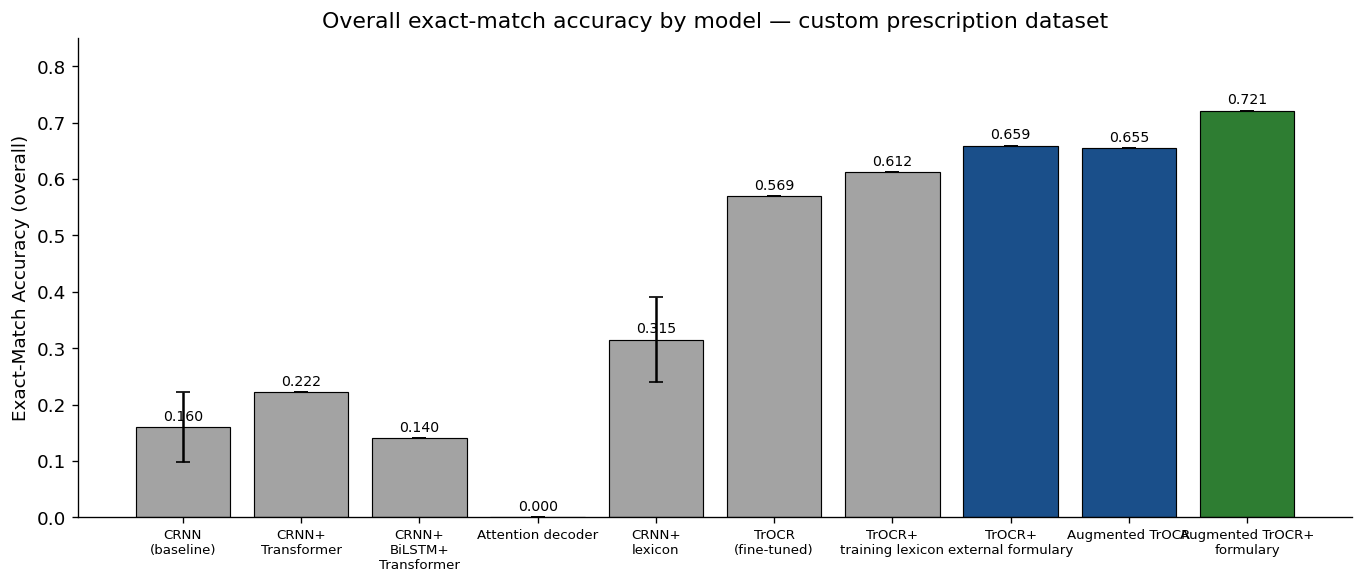

In [6]:
names=list(custom.keys())
short=[n.replace(" + ","+\n").replace(" (","\n(") for n in names]
ems=[custom[n]["EM"] for n in names]; sds=[custom[n]["EM_sd"] or 0 for n in names]
colors=[GREEN if "formulary" in n and "Augmented" in n else (BLUE if "formulary" in n or n=="Augmented TrOCR" else INK[2]) for n in names]
fig,ax=plt.subplots(figsize=(max(11,len(names)*1.15),5))
bars=ax.bar(short,ems,yerr=sds,capsize=4,color=colors,edgecolor="black",linewidth=0.7)
for b,v in zip(bars,ems): ax.text(b.get_x()+b.get_width()/2,v+0.012,f"{v:.3f}",ha="center",fontsize=8.5)
ax.set_ylabel("Exact-Match Accuracy (overall)"); ax.set_ylim(0,max(ems)*1.18)
ax.set_title("Overall exact-match accuracy by model — custom prescription dataset")
ax.spines[["top","right"]].set_visible(False); plt.xticks(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"final_fig1_overall_em.png"); plt.show()

## 5. HEADLINE Figure 2 — Overall CER by model

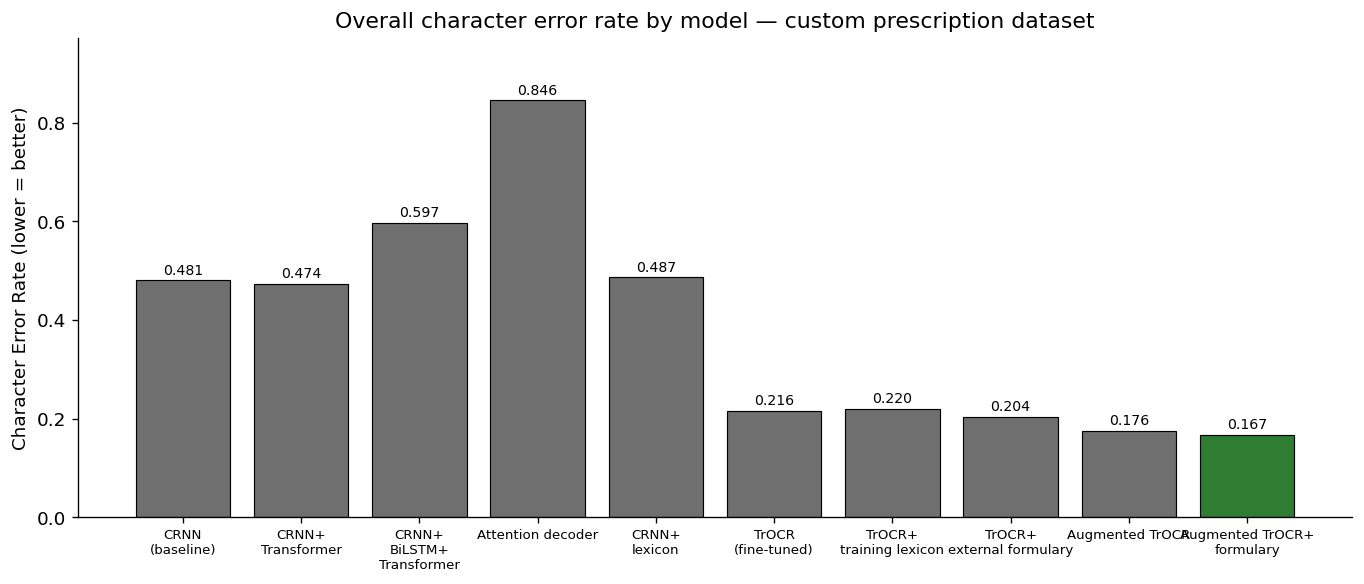

In [7]:
cers=[custom[n]["CER"] for n in names]
colors2=[GREEN if "formulary" in n and "Augmented" in n else INK[1] for n in names]
fig,ax=plt.subplots(figsize=(max(11,len(names)*1.15),5))
bars=ax.bar(short,cers,color=colors2,edgecolor="black",linewidth=0.7)
for b,v in zip(bars,cers): ax.text(b.get_x()+b.get_width()/2,v+0.012,f"{v:.3f}",ha="center",fontsize=8.5)
ax.set_ylabel("Character Error Rate (lower = better)"); ax.set_ylim(0,max(cers)*1.15)
ax.set_title("Overall character error rate by model — custom prescription dataset")
ax.spines[["top","right"]].set_visible(False); plt.xticks(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"final_fig2_overall_cer.png"); plt.show()

## 6. Figure 3 — The improvement progression (the story in one chart)

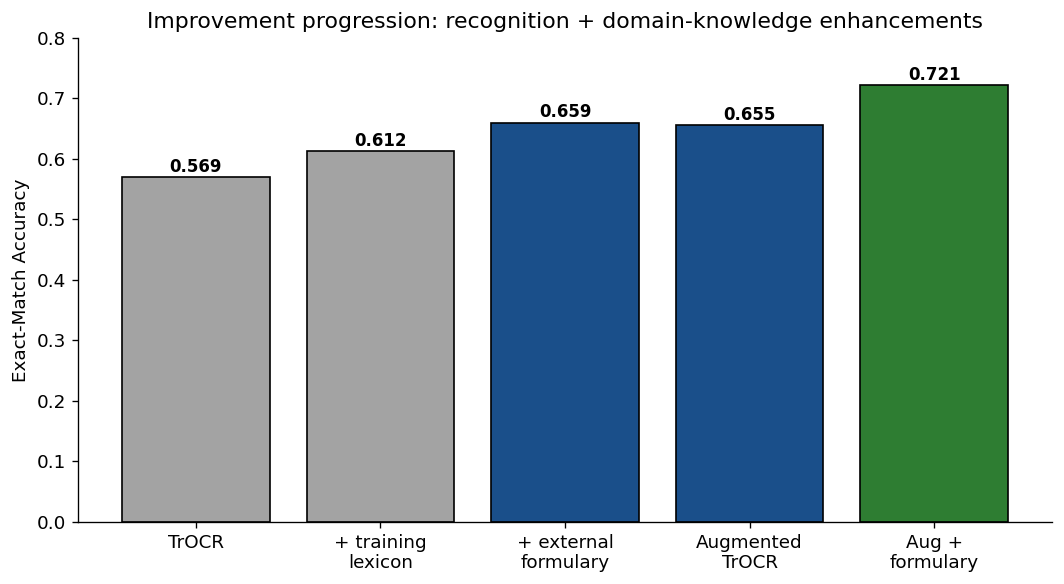

In [8]:
prog=["TrOCR","+ training\nlexicon","+ external\nformulary","Augmented\nTrOCR","Aug +\nformulary"]
prog_em=[0.569,0.612,0.659,0.655,0.721]
fig,ax=plt.subplots(figsize=(9,5))
bars=ax.bar(prog,prog_em,color=[INK[2],INK[2],BLUE,BLUE,GREEN],edgecolor="black")
for b,v in zip(bars,prog_em): ax.text(b.get_x()+b.get_width()/2,v+0.01,f"{v:.3f}",ha="center",fontsize=10,weight="bold")
ax.set_ylabel("Exact-Match Accuracy"); ax.set_ylim(0,0.8)
ax.set_title("Improvement progression: recognition + domain-knowledge enhancements")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig(FIG/"final_fig3_progression.png"); plt.show()

## 7. Figure 4 — Seen vs Unseen (the open-vocabulary story; the headline finding)
Shows the formulary SOLVING the unseen-name problem.

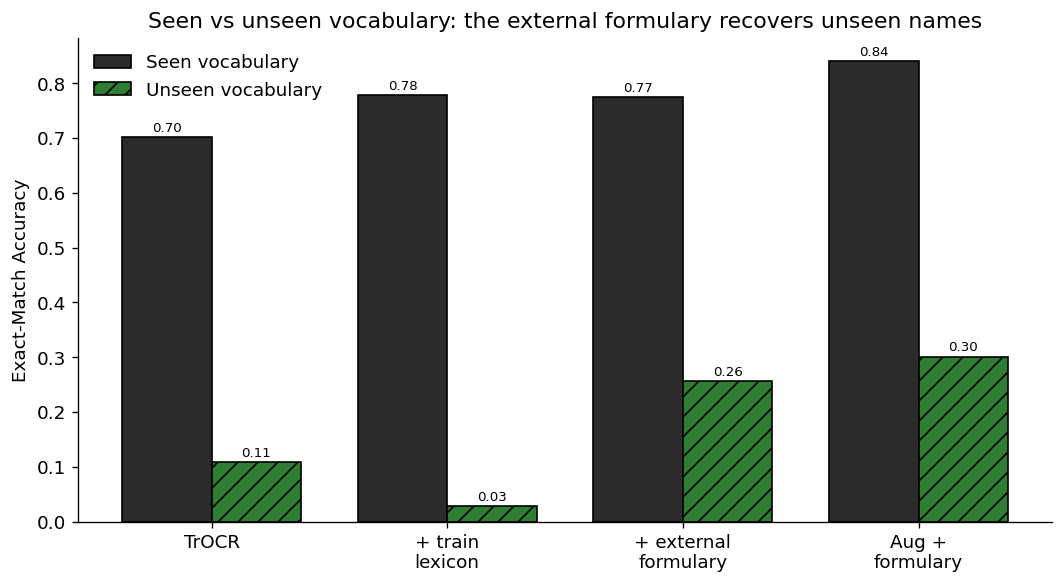

In [9]:
sel=["TrOCR (fine-tuned)","TrOCR + training lexicon","TrOCR + external formulary","Augmented TrOCR + formulary"]
sl=["TrOCR","+ train\nlexicon","+ external\nformulary","Aug +\nformulary"]
seen=[custom[m]["seen"] for m in sel]; unseen=[custom[m]["unseen"] for m in sel]
x=np.arange(len(sel)); w=0.38
fig,ax=plt.subplots(figsize=(9,5))
ax.bar(x-w/2,seen,w,label="Seen vocabulary",color=INK[0],edgecolor="black")
ax.bar(x+w/2,unseen,w,label="Unseen vocabulary",color=GREEN,edgecolor="black",hatch="//")
ax.set_xticks(x); ax.set_xticklabels(sl); ax.set_ylabel("Exact-Match Accuracy")
ax.set_title("Seen vs unseen vocabulary: the external formulary recovers unseen names")
ax.legend(frameon=False)
for i,(s,u) in enumerate(zip(seen,unseen)):
    ax.text(i-w/2,s+0.01,f"{s:.2f}",ha="center",fontsize=8)
    ax.text(i+w/2,u+0.01,f"{u:.2f}",ha="center",fontsize=8)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig(FIG/"final_fig4_seen_unseen.png"); plt.show()

## 8. Figure 5 — Cross-dataset generality + domain gap

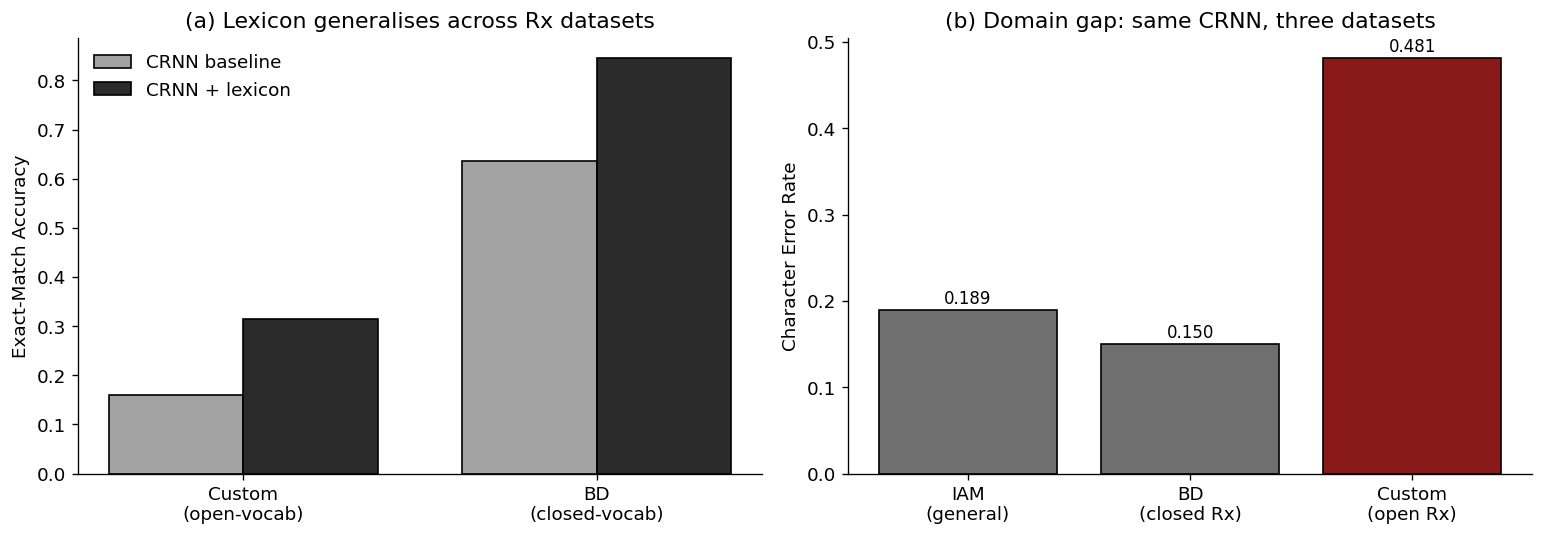

In [10]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.6))
# generality: lexicon helps on both Rx datasets
x=np.arange(2); w=0.38
a1.bar(x-w/2,[m0_em,0.636],w,label="CRNN baseline",color=INK[2],edgecolor="black")
a1.bar(x+w/2,[m2_em,0.845],w,label="CRNN + lexicon",color=INK[0],edgecolor="black")
a1.set_xticks(x); a1.set_xticklabels(["Custom\n(open-vocab)","BD\n(closed-vocab)"])
a1.set_ylabel("Exact-Match Accuracy"); a1.set_title("(a) Lexicon generalises across Rx datasets")
a1.legend(frameon=False); a1.spines[["top","right"]].set_visible(False)
# domain gap: same CRNN, 3 datasets
dgs=["IAM\n(general)","BD\n(closed Rx)","Custom\n(open Rx)"]; dcer=[0.189,0.150,m0_cer]
bars=a2.bar(dgs,dcer,color=[INK[1],INK[1],RED],edgecolor="black")
for b,v in zip(bars,dcer): a2.text(b.get_x()+b.get_width()/2,v+0.008,f"{v:.3f}",ha="center",fontsize=10)
a2.set_ylabel("Character Error Rate"); a2.set_title("(b) Domain gap: same CRNN, three datasets")
a2.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig(FIG/"final_fig5_generality_domaingap.png"); plt.show()

## 9. Significance + benchmark tables

In [11]:
t,p = stats.ttest_rel(seed_df["M2_EM"], seed_df["M0_EM"])
print(f"Significance (CRNN+lexicon vs CRNN, paired t-test): t={t:.3f}, p={p:.5f}, n={len(seed_df)}")
pd.DataFrame([{"comparison":"CRNN+lexicon vs CRNN","t":round(t,3),"p_value":f"{p:.5f}"}]).to_csv(TAB/"FINAL_significance.csv",index=False)

bd=pd.DataFrame({"CRNN baseline":{"CER":0.150,"EM":0.636},"CRNN + lexicon":{"CER":0.112,"EM":0.845},
                 "TrOCR":{"CER":0.046,"EM":0.941}}).T.reset_index().rename(columns={"index":"Model"})
bd.to_csv(TAB/"FINAL_bd.csv",index=False)
pd.DataFrame([{"dataset":"IAM-subset","CER":0.189,"EM":0.561}]).to_csv(TAB/"FINAL_iam.csv",index=False)
print("\nBD benchmark:"); print(bd.to_string(index=False))
print("\nIAM (domain-gap): CER 0.189 | EM 0.561")

Significance (CRNN+lexicon vs CRNN, paired t-test): t=17.842, p=0.00006, n=5

BD benchmark:
         Model   CER    EM
 CRNN baseline 0.150 0.636
CRNN + lexicon 0.112 0.845
         TrOCR 0.046 0.941

IAM (domain-gap): CER 0.189 | EM 0.561


## 10. Coverage diagnostic (for the formulary discussion)

In [12]:
print("External formulary coverage of unseen test names: 156/172 = 90.7%")
print("This high coverage is WHY the formulary recovers unseen names (0.028 -> 0.301 unseen EM).")
print("\nAll figures -> reports/figures/final_*.png ; tables -> reports/tables/FINAL_*.csv")
print("HEADLINE: best model = Augmented TrOCR + external formulary, EM 0.721 / CER 0.167.")

External formulary coverage of unseen test names: 156/172 = 90.7%
This high coverage is WHY the formulary recovers unseen names (0.028 -> 0.301 unseen EM).

All figures -> reports/figures/final_*.png ; tables -> reports/tables/FINAL_*.csv
HEADLINE: best model = Augmented TrOCR + external formulary, EM 0.721 / CER 0.167.
